# Input Dataset


In [1]:
# 1. The Movies Dataset
!kaggle datasets download -d rounakbanik/the-movies-dataset
!unzip -q the-movies-dataset.zip -d movies_data

# 2. Book Recommendation Dataset
!kaggle datasets download -d arashnic/book-recommendation-dataset
!unzip -q book-recommendation-dataset.zip -d books_data

Dataset URL: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
License(s): CC0-1.0
100% 228M/228M [00:02<00:00, 83.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset
License(s): CC0-1.0
100% 24.3M/24.3M [00:00<00:00, 94.2MB/s]



# Import Library

In [ ]:
!pip install pyspark
!apt-get install openjdk-8-jre # or openjdk-11-jre

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common librsvg2-common libxcomposite1 libxtst6
  libxxf86dga1 openjdk-8-jre-headless session-migration x11-utils
Suggested packages:
  gvfs libnss-mdns fonts-nanum fonts-ipafont-gothic fonts-ipafont-mincho
  fonts-wqy-microhei fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0
  libatk1.0-data libatspi2.0-0 libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common librsvg2-common libxcomposite1 l

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession



1.   Setup Spark



In [ ]:
# build spark
ss  = SparkSession.builder \
                            .master("local[1]")\
                            .appName("SparkByExamples.com")\
                            .config("spark.executor.memory", "8g") \
                            .config("spark.driver.memory", "4g") \
                            .getOrCreate()
spark = ss.sparkContext

# Collaborative Recommendation

Data Preprocessing

In [ ]:
ratings_df = ss.read.csv(path='books_data/Ratings.csv',
                        sep=',',
                        encoding='UTF-8',
                        comment=None,
                        header=True,
                        inferSchema=True)
ratings_df.show(n=5, truncate=False)

+-------+----------+-----------+
|User-ID|ISBN      |Book-Rating|
+-------+----------+-----------+
|276725 |034545104X|0          |
|276726 |0155061224|5          |
|276727 |0446520802|0          |
|276729 |052165615X|3          |
|276729 |0521795028|6          |
+-------+----------+-----------+
only showing top 5 rows


In [ ]:
# rename columns
ratings_df = ratings_df.withColumnRenamed('User-ID', 'userID')
ratings_df = ratings_df.withColumnRenamed('ISBN', 'isbn')
ratings_df = ratings_df.withColumnRenamed('Book-Rating', 'bookRating')
ratings_df.show(5)

+------+----------+----------+
|userID|      isbn|bookRating|
+------+----------+----------+
|276725|034545104X|         0|
|276726|0155061224|         5|
|276727|0446520802|         0|
|276729|052165615X|         3|
|276729|0521795028|         6|
+------+----------+----------+
only showing top 5 rows


In [ ]:
# count row dataframe
ratings_count = ratings_df.count()
print(f"count: {ratings_count}")

count: 1149780


In [ ]:
# filter ratings = 0 (only consider ratings that user had rated)
ratings_filtered_df = ratings_df.filter(ratings_df.bookRating != 0)
ratings_filtered_df.show(5)

+------+----------+----------+
|userID|      isbn|bookRating|
+------+----------+----------+
|276726|0155061224|         5|
|276729|052165615X|         3|
|276729|0521795028|         6|
|276736|3257224281|         8|
|276737|0600570967|         6|
+------+----------+----------+
only showing top 5 rows


In [ ]:
# count row dataframe
ratings_filtered_count = ratings_filtered_df.count()
print(f"count: {ratings_filtered_count}")
print(f"radio: {(ratings_filtered_count / ratings_count) * 100}")

count: 433671
radio: 37.71773730626728


In [ ]:
# data type
print(ratings_filtered_df.dtypes)
print('\n')
ratings_filtered_df.printSchema()

[('userID', 'int'), ('isbn', 'string'), ('bookRating', 'int')]


root
 |-- userID: integer (nullable = true)
 |-- isbn: string (nullable = true)
 |-- bookRating: integer (nullable = true)



In [ ]:
# convert pyspark dataframe -> pandas dataframe -> for data analysis
ratings_pd_df = ratings_filtered_df.toPandas()

In [ ]:
# ratings pandas dataframe information
ratings_pd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433671 entries, 0 to 433670
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   userID      433671 non-null  int32 
 1   isbn        433671 non-null  object
 2   bookRating  433671 non-null  int32 
dtypes: int32(2), object(1)
memory usage: 6.6+ MB


In [ ]:
# check null values
# ratings_pd_df.isnull().sum()

isnull_number = []
for i in ratings_pd_df.columns:
    x = ratings_pd_df[i].isnull().sum()
    isnull_number.append(x)

pd.DataFrame(isnull_number, index = ratings_pd_df.columns, columns = ["Total Missing Values"])

,Total Missing Values
userID,0
isbn,0
bookRating,0


In [ ]:
# ratings distinct count
ratings_pd_df["bookRating"].value_counts()

,count
bookRating,
8,103736
10,78610
7,76457
9,67541
5,50974
6,36924
4,8904
3,5996
2,2759


In [ ]:
# ratings columns count
print(ratings_pd_df["bookRating"].value_counts().sum())

433671


In [ ]:
# ratings distinct count
print(ratings_pd_df["bookRating"].value_counts().count())

10


In [ ]:
# dataframe describe
ratings_pd_df["bookRating"].describe().apply(lambda x: round(x, 2))

,bookRating
count,433671.00
mean,7.60
std,1.84
min,1.00
25%,7.00
50%,8.00
75%,9.00
max,10.00


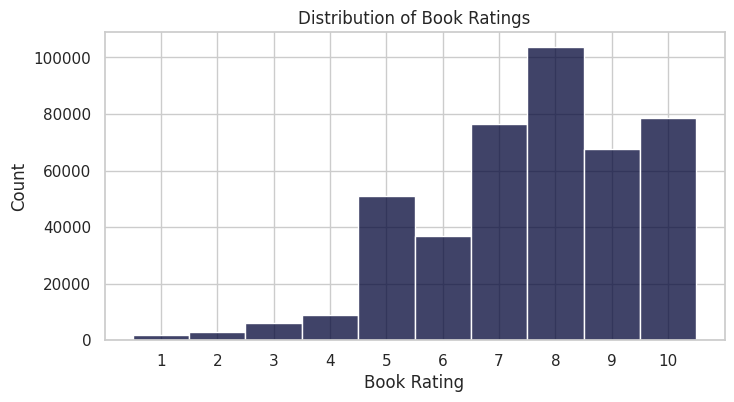

In [ ]:
# distribution of book ratings
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
sns.histplot( data=ratings_pd_df, x="bookRating", bins=np.arange(0.5, 10.5 + 1, 1), discrete=True, stat="count", color="#000435")

plt.xticks(range(1, 11))
plt.xlabel("Book Rating")
plt.ylabel("Count")
plt.title("Distribution of Book Ratings")
plt.show()

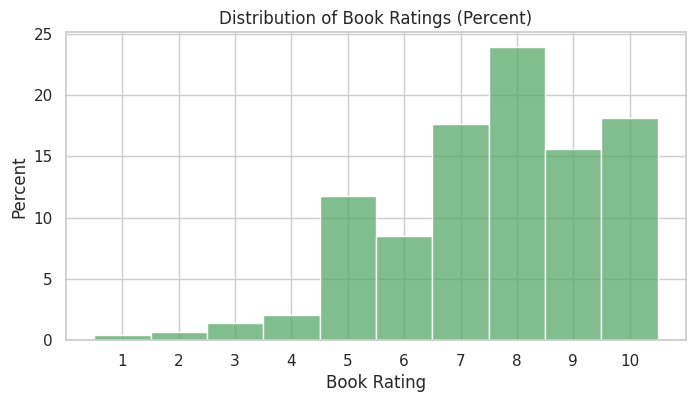

In [ ]:
# percentages of book ratings
plt.figure(figsize=(8, 4))
sns.histplot(data=ratings_pd_df, x="bookRating", bins=np.arange(0.5, 10.5 + 1, 1), discrete=True, stat="percent", color="#55A868")
plt.xticks(range(1, 11))
plt.xlabel("Book Rating")
plt.ylabel("Percent")
plt.title("Distribution of Book Ratings (Percent)")
plt.show()

In [ ]:
# after sorting isbn -> some values not integrity
ratings_pd_df.sort_values('isbn')

,userID,isbn,bookRating
292540,181817,0330299891,6
145998,89192,0375404120,3
18045,11676,9022906116,7
319738,199864,#6612432,5
412024,261539,'9607092910',10
...,...,...,...
431899,275414,"\8888809228""""""""",5
360452,227945,"\9170010242""""""""",10
418982,266146,ooo7156103,7
140661,86103,´3499128624,8


In [ ]:
# clean dirty isbn row
df = ratings_pd_df.copy()
df['isbn'] = (
    df['isbn'].astype(str)
      .str.upper()
      .str.replace(r'[^A-Z0-9]', '', regex=True)  # drop symbols/spaces/etc.
)

# drop rows which nothing remain after cleaning
df = df[df['isbn'].str.len() > 0].copy()

# keep plausible ISBN lengths (10 or 13)
df = df[df['isbn'].str.len().isin([10, 13])]

In [ ]:
# after cleaning isbn
df.sort_values('isbn')

,userID,isbn,bookRating
13808,8094,0000000000,10
18049,11676,0000000000,9
118476,71285,0000000000,7
414236,263063,0000000000,5
26759,11795,0000000000,7
...,...,...,...
140826,86153,VENAFRO001,8
26567,11676,X000000000,10
331916,208392,X113780760,7
52422,28586,X439361760,5


In [ ]:
# copy cleaned dataframe
ratings_cleaned_df = df.copy()

In [ ]:
# check distinct isbn
ratings_cleaned_df.nunique().rename('Count Distinct')

,Count Distinct
userID,76954
isbn,182328
bookRating,10


In [ ]:
# add isbn_index -> sort by isbn_index
ratings_cleaned_df['isbn_index'] = ratings_cleaned_df.groupby('isbn', sort=False).ngroup()  # 0-based
ratings_cleaned_df.sort_values('isbn_index')

,userID,isbn,bookRating,isbn_index
0,276726,0155061224,5,0
1,276729,052165615X,3,1
2,276729,0521795028,6,2
199120,119485,3257224281,5,3
141512,86583,3257224281,6,3
...,...,...,...,...
433641,276688,0425156737,2,182323
433652,276688,0671563149,6,182324
433662,276688,1575660792,7,182325
433664,276704,0380796155,5,182326


In [ ]:
# Output .csv
df = ratings_cleaned_df.sort_values('isbn')
result = pd.DataFrame({'userID': df["userID"], 'isbn': df["isbn"], 'bookRating': df["bookRating"], 'isbn_index': df["isbn_index"]})
file = 'ratings_without0_cleaned.csv'
result.to_csv(file, index=False)

In [ ]:
# ratings_cleaned_df -> can use for training model

# Data Cleaning

In [ ]:
ratings_spark_df = ss.read.csv(path='ratings_without0_cleaned.csv',
                        sep=',',
                        encoding='UTF-8',
                        comment=None,
                        header=True,
                        inferSchema=True)
ratings_spark_df.show(n=5, truncate=False)

+------+----------+----------+----------+
|userID|isbn      |bookRating|isbn_index|
+------+----------+----------+----------+
|8094  |0000000000|10        |11400     |
|11676 |0000000000|9         |11400     |
|71285 |0000000000|7         |11400     |
|263063|0000000000|5         |11400     |
|11795 |0000000000|7         |11400     |
+------+----------+----------+----------+
only showing top 5 rows


In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

# ALS Algorithm

In [ ]:
# import pyspark & recommenders library
import sys
import pyspark
from pyspark.ml.recommendation import ALS
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField
from pyspark.sql.types import StringType, FloatType, IntegerType, LongType

1. Init

In [ ]:
# print system info
print(f"System version: {sys.version}")
print("Spark version: {}".format(pyspark.__version__))

System version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Spark version: 4.0.1


In [ ]:
# top k items to recommend
TOP_K = 5

In [ ]:
# convert pandas dataframe -> pyspark dataframe
ratings_spark_df = ss.createDataFrame(ratings_cleaned_df)

NameError: name 'ratings_cleaned_df' is not defined

2. Split Random Data

In [ ]:
# use pyspark dataframe -> prediction
train, test = ratings_spark_df.randomSplit([0.8, 0.2], seed=42)

In [ ]:
train.show(5)
train.count()

+------+----------+----------+----------+
|userID|      isbn|bookRating|isbn_index|
+------+----------+----------+----------+
|     8|0002005018|         5|      2234|
|     8|074322678X|         5|      2235|
|     8|1552041778|         5|      2237|
|     8|1567407781|         6|      2238|
|     8|1575663937|         6|      2239|
+------+----------+----------+----------+
only showing top 5 rows


343840

In [ ]:
test.show(5)
test.count()

+------+----------+----------+----------+
|userID|      isbn|bookRating|isbn_index|
+------+----------+----------+----------+
|     8|0887841740|         5|      2236|
|     8|1881320189|         7|      2240|
|    10|8477024456|         6|      2242|
|    16|0345402871|         9|      2247|
|    22|3404921038|         7|      2253|
+------+----------+----------+----------+
only showing top 5 rows


86110

2.1 Build ALS Model

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

In [ ]:
ratings_spark_df = ratings_spark_df.withColumn("userID", col("userID").cast("int")) \
.withColumn("isbn_index", col("isbn_index").cast("int")) \
.withColumn("bookRating", col("bookRating").cast("int"))

In [ ]:
ratings_spark_df.count()

429950

In [ ]:
# Build the recommendation model using ALS on the training data
als = ALS(maxIter=5, regParam=0.01, userCol="userID", itemCol="isbn_index", ratingCol="bookRating")
model = als.fit(train)

In [ ]:
# Evaluate the model by computing the RMSE on the test data
predictions = model.transform(test)
predictions.show(10)

# Evaluate the model by computing the RMSE on the test data
evaluator = RegressionEvaluator(metricName="rmse", labelCol="bookRating",predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root-mean-square error = " + str(rmse))

+------+----------+----------+----------+----------+
|userID|      isbn|bookRating|isbn_index|prediction|
+------+----------+----------+----------+----------+
|     8|0887841740|         5|      2236|       NaN|
|     8|1881320189|         7|      2240|-1.6441454|
|    10|8477024456|         6|      2242|       NaN|
|    16|0345402871|         9|      2247|       NaN|
|    22|3404921038|         7|      2253|       NaN|
|    39|0553582909|         8|      2255|  2.923117|
|    53|0156047624|        10|      2259|0.42007583|
|    67|0394743741|         7|      2265|       NaN|
|    83|087113375X|         7|      2274|       NaN|
|    85|0340767936|         5|      2275|       NaN|
+------+----------+----------+----------+----------+
only showing top 10 rows
Root-mean-square error = nan


In [ ]:
row_list = predictions.select("prediction")

In [ ]:
row_list

DataFrame[prediction: float]

In [ ]:
nan_cnt = predictions.filter(isnan(col("prediction"))).count()
print(nan_cnt)

34794


In [ ]:
valid_cnt = predictions.filter(~isnan(col("prediction")) & col("prediction").isNotNull()).count()
print(valid_cnt)

51316


In [ ]:
predictions.count()

86110

2.2 Build ALS Model (filter nan prediction)

In [ ]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

In [ ]:
# Build ALS recommendation model -> training data
als = ALS(maxIter=10, regParam=0.2, userCol="userID", itemCol="isbn_index", ratingCol="bookRating", coldStartStrategy="drop", nonnegative=True)
model = als.fit(train)

In [ ]:
paramGrid = (ParamGridBuilder().addGrid(als.rank, [8, 16, 32, 64]).addGrid(als.regParam, [0.001, 0.01, 0.05, 0.1, 0.2]).build())

In [ ]:
# Evaluate RMSE -> on test data
predictions = model.transform(test)
predictions.show(10)

# Evaluate RMSE -> on test data
evaluator = RegressionEvaluator(metricName="rmse", labelCol="bookRating",predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print("Root-mean-square error = " + str(rmse))

+------+----------+----------+----------+----------+
|userID|      isbn|bookRating|isbn_index|prediction|
+------+----------+----------+----------+----------+
|240643|038550120X|         9|         5|  7.563605|
|235146|038550120X|        10|         5|  8.103078|
| 31315|038550120X|         6|         5|  7.186002|
|215988|038550120X|        10|         5| 6.0787783|
|187256|038550120X|         9|         5| 7.6205263|
|193778|038550120X|        10|         5|   8.47412|
| 20806|038550120X|         6|         5| 5.9113817|
|109180|038550120X|        10|         5|  7.182016|
| 37800|038550120X|         9|         5| 5.0590386|
|265202|038550120X|         8|         5| 6.6670723|
+------+----------+----------+----------+----------+
only showing top 10 rows
Root-mean-square error = 2.2881830242361434


In [ ]:
# cross validation
# tvs = TrainValidationSplit(estimator=als, estimatorParamMaps=paramGrid, evaluator=evaluator, trainRatio=0.8) # simple and cheap vs CV

# tuned_model = tvs.fit(train)
# best_model = tuned_model.bestModel
# preds = best_model.transform(test)
# rmse = evaluator.evaluate(preds)
# print("Best rank:", best_model._java_obj.parent().getRank(), "Best regParam:", best_model._java_obj.parent().getRegParam(), "RMSE:", rmse)

Best rank: 32 Best regParam: 0.2 RMSE: 2.279602064226759


In [ ]:
# recommend for user
from pyspark.sql.functions import explode, col
target_user = 31556
users_df = ss.createDataFrame([(target_user,)], ["userID"])
rec = model.recommendForUserSubset(users_df, 5)
rec = (rec.select("userID", explode("recommendations") \
          .alias("r")) \
          .select("userID", col("r."+model.getItemCol()) \
          .alias("isbn_index"), col("r.rating") \
          .alias("score")))

In [ ]:
rec.show()

+------+----------+---------+
|userID|isbn_index|    score|
+------+----------+---------+
| 31556|     99670|11.305893|
| 31556|     11860| 11.03821|
| 31556|    117438|10.968794|
| 31556|    117435|10.968794|
| 31556|    160844|10.888868|
+------+----------+---------+



In [ ]:
rec = rec.join(ratings_spark_df.select("isbn_index", "isbn"), on="isbn_index", how="left").orderBy(col("score").desc())

In [ ]:
rec.show()

+----------+------+---------+----------+
|isbn_index|userID|    score|      isbn|
+----------+------+---------+----------+
|     99670| 31556|11.305893|0312144512|
|     99670| 31556|11.305893|0312144512|
|     11860| 31556| 11.03821|3518100122|
|    117438| 31556|10.968794|9590804535|
|    117435| 31556|10.968794|8420646237|
|    160844| 31556|10.888868|0704381389|
+----------+------+---------+----------+



In [ ]:
predictions.groupBy("userID").count().show()

+------+-----+
|userID|count|
+------+-----+
| 73091|    1|
|105536|    3|
| 26706|    1|
|178199|   16|
| 23571|   11|
|168802|    3|
|271086|    3|
|132171|    5|
|271557|    2|
|195901|    2|
|261768|    1|
| 43852|    1|
|   496|    1|
|274549|    4|
| 57039|    1|
|101475|    1|
|141533|    2|
|268622|    6|
|118185|    1|
|213312|    6|
+------+-----+
only showing top 20 rows


In [ ]:
predictions.groupBy("isbn_index").count().show()

+----------+-----+
|isbn_index|count|
+----------+-----+
|         5|   10|
|         6|    9|
|         7|    3|
|         8|    5|
|        13|    7|
|        14|   12|
|        16|    4|
|        17|    1|
|        20|    1|
|        21|    1|
|        27|    1|
|        29|    1|
|        30|    4|
|        31|   28|
|        32|    3|
|        33|   15|
|        34|    1|
|        36|    3|
|        38|   13|
|        40|    1|
+----------+-----+
only showing top 20 rows


In [ ]:
spark.stop()

# Content-Based Filtering One-Hot Vector

**Data preprocessing**

In [2]:
# movie dataset loading
import pandas as pd

movies_data = 'movies_data/movies_metadata.csv'
ratings_data = 'movies_data/ratings_small.csv'
links_data = 'movies_data/links_small.csv'
movies_df = pd.read_csv(movies_data)
ratings_df = pd.read_csv(ratings_data)
links_df = pd.read_csv(links_data)

/tmp/ipykernel_12889/2310886920.py:7: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_df = pd.read_csv(movies_data)


In [3]:
movies_df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [4]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [5]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [6]:
# check shape
print('movies_df shape:', movies_df.shape)
print('ratings_df shape:', ratings_df.shape)
print('links_df shape', links_df.shape)

movies_df shape: (45466, 24)
ratings_df shape: (100004, 4)
links_df shape (9125, 3)


In [7]:
# check ratings missing values
ratings_df.isna().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [8]:
# check movies missing values
movies_df.isna().sum()

,0
adult,0
belongs_to_collection,40972
budget,0
genres,0
homepage,37684
id,0
imdb_id,17
original_language,11
original_title,0
overview,954


In [9]:
# check links missing values
links_df.isna().sum()

,0
movieId,0
imdbId,0
tmdbId,13


In [10]:
# count unique userID in ratings_df
print(len(ratings_df["userId"].unique()))

671


In [11]:
# count unique movieID in ratings_df
print(len(ratings_df['movieId'].unique()))

9066


In [12]:
# default pandas setting
pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')

In [ ]:
# modify pandas setting
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)

In [13]:
movies_df[['id','imdb_id','genres','title','overview']].head()

,id,imdb_id,genres,title,overview
0,862,tt0114709,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,tt0113497,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Jumanji,When siblings Judy and Peter discover an encha...
2,15602,tt0113228,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,tt0114885,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,tt0113041,"[{'id': 35, 'name': 'Comedy'}]",Father of the Bride Part II,Just when George Banks has recovered from his ...


In [14]:
# filter unnecessary column
movie_filtered_df = movies_df[['id','genres','title','overview']].copy()

In [15]:
movie_filtered_df.head()

,id,genres,title,overview
0,862,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Jumanji,When siblings Judy and Peter discover an encha...
2,15602,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,"[{'id': 35, 'name': 'Comedy'}]",Father of the Bride Part II,Just when George Banks has recovered from his ...


In [16]:
# modify genres
import ast

# 1) convert string representation -> real list of dicts
movie_filtered_df['genres'] = movie_filtered_df['genres'].apply(ast.literal_eval)

# 2) store genres -> string format (seperate by | )
movie_filtered_df['genres'] = movie_filtered_df['genres'].apply(
    lambda g: "|".join(d["name"] for d in g) if isinstance(g, list) else ""
)

movie_filtered_df.head()

,id,genres,title,overview
0,862,Animation|Comedy|Family,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,Adventure|Fantasy|Family,Jumanji,When siblings Judy and Peter discover an encha...
2,15602,Romance|Comedy,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,Comedy|Drama|Romance,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,Comedy,Father of the Bride Part II,Just when George Banks has recovered from his ...


In [17]:
# rename if -> tmdb_id (matching)
movie_filtered_df = movie_filtered_df.rename(columns={'id': 'tmdbId'})
movie_filtered_df.head()

,tmdbId,genres,title,overview
0,862,Animation|Comedy|Family,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,Adventure|Fantasy|Family,Jumanji,When siblings Judy and Peter discover an encha...
2,15602,Romance|Comedy,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,Comedy|Drama|Romance,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,Comedy,Father of the Bride Part II,Just when George Banks has recovered from his ...


In [18]:
# check missing values again
movie_filtered_df.isna().sum()

,0
tmdbId,0
genres,0
title,6
overview,954


**One-Hot Vector**

In [19]:
# store the genres in list format
movie_filtered_df['genres'] = movie_filtered_df['genres'].str.split('|')
movie_filtered_df.head()

,tmdbId,genres,title,overview
0,862,"[Animation, Comedy, Family]",Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,"[Adventure, Fantasy, Family]",Jumanji,When siblings Judy and Peter discover an encha...
2,15602,"[Romance, Comedy]",Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,"[Comedy, Drama, Romance]",Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,[Comedy],Father of the Bride Part II,Just when George Banks has recovered from his ...


In [20]:
# filter links_df (only movieId, tmdbId)
links_filtered_df = links_df[['movieId', 'tmdbId']].copy()
links_filtered_df.head()

,movieId,tmdbId
0,1,862.0
1,2,8844.0
2,3,15602.0
3,4,31357.0
4,5,11862.0


In [21]:
movie_filtered_df.head()

,tmdbId,genres,title,overview
0,862,"[Animation, Comedy, Family]",Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,8844,"[Adventure, Fantasy, Family]",Jumanji,When siblings Judy and Peter discover an encha...
2,15602,"[Romance, Comedy]",Grumpier Old Men,A family wedding reignites the ancient feud be...
3,31357,"[Comedy, Drama, Romance]",Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,11862,[Comedy],Father of the Bride Part II,Just when George Banks has recovered from his ...


In [22]:
# movie_filtered_df data cleaning -> convert non-numeric values -> NaN
count = pd.to_numeric(movie_filtered_df['tmdbId'], errors='coerce').isna().sum()
print('invalid data count:', count)
movie_filtered_df[pd.to_numeric(movie_filtered_df['tmdbId'], errors='coerce').isna()]['tmdbId'].head()

invalid data count: 3


,tmdbId
19730,1997-08-20
29503,2012-09-29
35587,2014-01-01


In [23]:
# links_filtered_df data cleaning -> convert non-numeric values -> NaN
count = pd.to_numeric(links_filtered_df['tmdbId'], errors='coerce').isna().sum()
print('invalid data count:', count)
links_filtered_df[pd.to_numeric(links_filtered_df['tmdbId'], errors='coerce').isna()]['tmdbId'].head()

invalid data count: 13


,tmdbId
607,NaN
608,NaN
640,NaN
910,NaN
2282,NaN


In [24]:
# drop invalid data
movie_filtered_df['tmdbId'] = pd.to_numeric(movie_filtered_df['tmdbId'], errors='coerce')
links_filtered_df['tmdbId'] = pd.to_numeric(links_filtered_df['tmdbId'], errors='coerce')

movie_filtered_df = movie_filtered_df.dropna(subset=['tmdbId'])
links_filtered_df = links_filtered_df.dropna(subset=['tmdbId'])

In [25]:
# ensure same dtype

# avoid affect original data
movie_filtered_df = movie_filtered_df.copy()
links_filtered_df = links_filtered_df.copy()

movie_filtered_df['tmdbId'] = movie_filtered_df['tmdbId'].astype(int)
links_filtered_df['tmdbId'] = links_filtered_df['tmdbId'].astype(int)

movie_merged_df = movie_filtered_df.merge(links_filtered_df, on='tmdbId', how='inner').copy()
movie_merged_df.head()

,tmdbId,genres,title,overview,movieId
0,862,"[Animation, Comedy, Family]",Toy Story,"Led by Woody, Andy's toys live happily in his ...",1
1,8844,"[Adventure, Fantasy, Family]",Jumanji,When siblings Judy and Peter discover an encha...,2
2,15602,"[Romance, Comedy]",Grumpier Old Men,A family wedding reignites the ancient feud be...,3
3,31357,"[Comedy, Drama, Romance]",Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",4
4,11862,[Comedy],Father of the Bride Part II,Just when George Banks has recovered from his ...,5


In [26]:
# copy movie_merged_df -> only movie & genres
movie_genres_df = movie_merged_df[['movieId', 'title', 'genres']].copy(deep=True)
movie_genres_df.head()

,movieId,title,genres
0,1,Toy Story,"[Animation, Comedy, Family]"
1,2,Jumanji,"[Adventure, Fantasy, Family]"
2,3,Grumpier Old Men,"[Romance, Comedy]"
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II,[Comedy]


In [27]:
# expand genre -> One-Hot Vector
genre_list = [] # store the occurred genres

for index, row in movie_genres_df.iterrows():
    for genre in row['genres']:
        movie_genres_df.at[index, genre] = 1
        if genre not in genre_list:
            genre_list.append(genre)

movie_genres_df.head()

,movieId,title,genres,Animation,Comedy,Family,Adventure,Fantasy,Romance,Drama,...,History,Science Fiction,Mystery,War,Foreign,Music,Documentary,,Western,TV Movie
0,1,Toy Story,"[Animation, Comedy, Family]",1.0,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Jumanji,"[Adventure, Fantasy, Family]",NaN,NaN,1.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Grumpier Old Men,"[Romance, Comedy]",NaN,1.0,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]",NaN,1.0,NaN,NaN,NaN,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Father of the Bride Part II,[Comedy],NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# let NaN = 0
movie_genres_df = movie_genres_df.fillna(0)
movie_genres_df.head()

,movieId,title,genres,Animation,Comedy,Family,Adventure,Fantasy,Romance,Drama,...,History,Science Fiction,Mystery,War,Foreign,Music,Documentary,,Western,TV Movie
0,1,Toy Story,"[Animation, Comedy, Family]",1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji,"[Adventure, Fantasy, Family]",0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men,"[Romance, Comedy]",0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]",0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Father of the Bride Part II,[Comedy],0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
# genre category
genre_list

['Animation',
 'Comedy',
 'Family',
 'Adventure',
 'Fantasy',
 'Romance',
 'Drama',
 'Action',
 'Crime',
 'Thriller',
 'Horror',
 'History',
 'Science Fiction',
 'Mystery',
 'War',
 'Foreign',
 'Music',
 'Documentary',
 '',
 'Western',
 'TV Movie']

In [30]:
# rename empty genre
genre_list = ['Empty' if genre == '' else genre for genre in genre_list]
genre_list

['Animation',
 'Comedy',
 'Family',
 'Adventure',
 'Fantasy',
 'Romance',
 'Drama',
 'Action',
 'Crime',
 'Thriller',
 'Horror',
 'History',
 'Science Fiction',
 'Mystery',
 'War',
 'Foreign',
 'Music',
 'Documentary',
 'Empty',
 'Western',
 'TV Movie']

In [31]:
movie_genres_df = movie_genres_df.rename(columns={'': 'Empty'})
movie_genres_df.head()

,movieId,title,genres,Animation,Comedy,Family,Adventure,Fantasy,Romance,Drama,...,History,Science Fiction,Mystery,War,Foreign,Music,Documentary,Empty,Western,TV Movie
0,1,Toy Story,"[Animation, Comedy, Family]",1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji,"[Adventure, Fantasy, Family]",0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men,"[Romance, Comedy]",0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Waiting to Exhale,"[Comedy, Drama, Romance]",0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Father of the Bride Part II,[Comedy],0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# obtain a numpy matrix, which will be used for computing similarities later
movie_genres_matrix = movie_genres_df[genre_list].to_numpy()
movie_genres_matrix

array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

**User Profiles**

In [33]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [34]:
# assume build user preference with userID = 200
user_rating_df = ratings_df[ratings_df['userId'] == 200]
user_rating_df

,userId,movieId,rating,timestamp
27425,200,1,3.0,1437932719
27426,200,2,3.5,1457721108
27427,200,32,4.0,1437934584
27428,200,110,3.5,1438019199
27429,200,145,4.5,1437933154
...,...,...,...,...
27673,200,106920,3.5,1438025417
27674,200,111659,4.0,1438026414
27675,200,129354,4.0,1457720823
27676,200,134130,4.5,1457123787


Separate traing & test data (80% train, 20% test)

In [35]:
# separate
user_preference_df = user_rating_df.sample(frac=0.2, random_state=2)
user_preference_df = user_preference_df.reset_index(drop=True)
user_preference_df

,userId,movieId,rating,timestamp
0,200,2011,4.5,1437933259
1,200,377,3.5,1438019501
2,200,8622,1.5,1438020315
3,200,4306,4.5,1437933791
4,200,31685,2.5,1438019979
5,200,2762,1.5,1438024902
6,200,4016,1.0,1438022765
7,200,1291,4.5,1438023102
8,200,110,3.5,1438019199
9,200,5809,1.0,1438024335


In [36]:
# movie_genres_df do not have movieId == 90647 (missing data)
movie_genres_df[movie_genres_df['movieId'] == 90647]

,movieId,title,genres,Animation,Comedy,Family,Adventure,Fantasy,Romance,Drama,...,History,Science Fiction,Mystery,War,Foreign,Music,Documentary,Empty,Western,TV Movie


In [37]:
# merge movie, genre, user df
user_rating_movie_df = pd.merge(user_preference_df, movie_genres_df)
user_rating_movie_df.head()

,userId,movieId,rating,timestamp,title,genres,Animation,Comedy,Family,Adventure,...,History,Science Fiction,Mystery,War,Foreign,Music,Documentary,Empty,Western,TV Movie
0,200,2011,4.5,1437933259,Back to the Future Part II,"[Adventure, Comedy, Family, Science Fiction]",0.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,200,377,3.5,1438019501,Speed,"[Action, Adventure, Crime]",0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,200,8622,1.5,1438020315,Fahrenheit 9/11,[],0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,200,4306,4.5,1437933791,Shrek,"[Adventure, Animation, Comedy, Family, Fantasy]",1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,200,31685,2.5,1438019979,Hitch,"[Comedy, Drama, Romance]",0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
# One-Hot Vector (genres)
user_genres_df = user_rating_movie_df.copy()
# filter genre_list
user_genres_df = user_genres_df[genre_list]
# show
user_genres_df.head()

,Animation,Comedy,Family,Adventure,Fantasy,Romance,Drama,Action,Crime,Thriller,...,History,Science Fiction,Mystery,War,Foreign,Music,Documentary,Empty,Western,TV Movie
0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Aggregate

In [39]:
# shape
print('user_preference_df shape:', user_preference_df.shape)
print('user_rating_movie_df shape', user_rating_movie_df.shape)
print('user_genres_df shape', user_genres_df.shape)

user_preference_df shape: (51, 4)
user_rating_movie_df shape (51, 27)
user_genres_df shape (51, 21)


In [40]:
user_preference_df = user_rating_movie_df[['userId', 'movieId', 'rating', 'timestamp']]
user_preference_df

,userId,movieId,rating,timestamp
0,200,2011,4.5,1437933259
1,200,377,3.5,1438019501
2,200,8622,1.5,1438020315
3,200,4306,4.5,1437933791
4,200,31685,2.5,1438019979
5,200,2762,1.5,1438024902
6,200,4016,1.0,1438022765
7,200,1291,4.5,1438023102
8,200,110,3.5,1438019199
9,200,5809,1.0,1438024335


In [41]:
# check shape again (make sure dot multiplication correct)
print('user_preference_df shape:', user_preference_df.shape)
print('user_rating_movie_df shape', user_rating_movie_df.shape)
print('user_genres_df shape', user_genres_df.shape)

user_preference_df shape: (51, 4)
user_rating_movie_df shape (51, 27)
user_genres_df shape (51, 21)


In [42]:
# weighted rating
weighted_rating_weight = user_preference_df.rating / user_preference_df.rating.sum()

# dot
weighted_user_profile = user_genres_df.T.dot(weighted_rating_weight)

# normalization
weighted_user_profile_normalized = weighted_user_profile / sum(weighted_user_profile.values)

weighted_user_profile_normalized

,0
Animation,0.069680
Comedy,0.116761
Family,0.095104
Adventure,0.132768
Fantasy,0.033898
Romance,0.067797
Drama,0.102637
Action,0.107345
Crime,0.058380
Thriller,0.077213


In [43]:
weighted_rating_weight

,rating
0,0.025568
1,0.019886
2,0.008523
3,0.025568
4,0.014205
5,0.008523
6,0.005682
7,0.025568
8,0.019886
9,0.005682


In [44]:
weighted_user_profile

,0
Animation,0.210227
Comedy,0.352273
Family,0.286932
Adventure,0.400568
Fantasy,0.102273
Romance,0.204545
Drama,0.309659
Action,0.323864
Crime,0.176136
Thriller,0.232955


Recommendation

In [45]:
# filtered (movieId, title, genres list) also same as movie_genres_matrix
movie_genres_one_hot_df = movie_genres_df[genre_list]
print(len(movie_genres_one_hot_df))
movie_genres_one_hot_df.head()

9099


,Animation,Comedy,Family,Adventure,Fantasy,Romance,Drama,Action,Crime,Thriller,...,History,Science Fiction,Mystery,War,Foreign,Music,Documentary,Empty,Western,TV Movie
0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
# show movie_genres_matrix
movie_genres_matrix

array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [47]:
import numpy as np

# weighted user profile
user_preferences_values = weighted_user_profile_normalized.values
upv_matrix = np.array([user_preferences_values] * len(movie_genres_one_hot_df))

# Predict user preferences towards items
prediction_score = np.multiply(upv_matrix, movie_genres_matrix)

prediction_score = prediction_score.sum(axis=1)
prediction_score

array([0.28154426, 0.26177024, 0.18455744, ..., 0.43879473, 0.38700565,
       0.21939736])

In [48]:
len(prediction_score)

9099

In [49]:
user_preferences_values

array([0.06967985, 0.11676083, 0.09510358, 0.13276836, 0.03389831,
       0.06779661, 0.10263653, 0.10734463, 0.05838041, 0.07721281,
       0.00564972, 0.01506591, 0.05555556, 0.03389831, 0.02354049,
       0.        , 0.00188324, 0.        , 0.00282486, 0.        ,
       0.        ])

In [50]:
upv_matrix

array([[0.06967985, 0.11676083, 0.09510358, ..., 0.00282486, 0.        ,
        0.        ],
       [0.06967985, 0.11676083, 0.09510358, ..., 0.00282486, 0.        ,
        0.        ],
       [0.06967985, 0.11676083, 0.09510358, ..., 0.00282486, 0.        ,
        0.        ],
       ...,
       [0.06967985, 0.11676083, 0.09510358, ..., 0.00282486, 0.        ,
        0.        ],
       [0.06967985, 0.11676083, 0.09510358, ..., 0.00282486, 0.        ,
        0.        ],
       [0.06967985, 0.11676083, 0.09510358, ..., 0.00282486, 0.        ,
        0.        ]])

In [51]:
len(movie_genres_one_hot_df)

9099

In [52]:
# calculate all movie rank score with current user preferences
recommendation_df = movie_genres_df[['movieId', 'title']].copy(deep=True)
recommendation_df['rankingScore'] = prediction_score
recommendation_df

,movieId,title,rankingScore
0,1,Toy Story,0.281544
1,2,Jumanji,0.261770
2,3,Grumpier Old Men,0.184557
3,4,Waiting to Exhale,0.287194
4,5,Father of the Bride Part II,0.116761
...,...,...,...
9094,163056,Shin Godzilla,0.403955
9095,163949,The Beatles: Eight Days a Week - The Touring Y...,0.001883
9096,4241,Pokémon: Spell of the Unknown,0.438795
9097,5672,Pokémon 4Ever: Celebi - Voice of the Forest,0.387006


In [53]:
# show top 10 recommendation
sorted_rec_df = recommendation_df.sort_values(by="rankingScore", ascending=False)
sorted_rec_df

,movieId,title,rankingScore
5541,8811,Yu-Gi-Oh! The Movie,0.688324
3282,4115,Hiding Out,0.631827
3944,5106,Crossroads,0.624294
6511,48159,Everyone's Hero,0.624294
4231,5629,Jonah: A VeggieTales Movie,0.623352
...,...,...,...
8137,97395,West of Memphis,0.000000
5473,8625,The Same River Twice,0.000000
8018,94024,Louis Theroux: America's Most Hated Family in ...,0.000000
6992,60763,American Teen,0.000000


In [54]:
# filter movie that user already viewed

# count
print('unique movie viewed count: ', user_preference_df['movieId'].nunique())
user_unique_pre_df = user_preference_df['movieId'].unique()

unique movie viewed count:  51


In [55]:
# top k recommendation list
k = 10
top_k_rec = []

for rec_movie_id in sorted_rec_df['movieId'].values:
    # not viewed
    if rec_movie_id not in user_unique_pre_df:
        top_k_rec.append(rec_movie_id)
    if len(top_k_rec)==k:
        break

top_k_rec

[np.int64(8811),
 np.int64(4115),
 np.int64(5106),
 np.int64(48159),
 np.int64(5629),
 np.int64(4990),
 np.int64(2414),
 np.int64(40959),
 np.int64(1429),
 np.int64(970)]

Evaluation Preprocessing

In [56]:
user_rating_df = ratings_df[ratings_df['userId'] == 200]
user_rating_df

,userId,movieId,rating,timestamp
27425,200,1,3.0,1437932719
27426,200,2,3.5,1457721108
27427,200,32,4.0,1437934584
27428,200,110,3.5,1438019199
27429,200,145,4.5,1437933154
...,...,...,...,...
27673,200,106920,3.5,1438025417
27674,200,111659,4.0,1438026414
27675,200,129354,4.0,1457720823
27676,200,134130,4.5,1457123787


In [57]:
user_preference_df

,userId,movieId,rating,timestamp
0,200,2011,4.5,1437933259
1,200,377,3.5,1438019501
2,200,8622,1.5,1438020315
3,200,4306,4.5,1437933791
4,200,31685,2.5,1438019979
5,200,2762,1.5,1438024902
6,200,4016,1.0,1438022765
7,200,1291,4.5,1438023102
8,200,110,3.5,1438019199
9,200,5809,1.0,1438024335


In [58]:
# find ground truth list (movie that really liked, condition > 3)
train_data = list(user_preference_df['movieId'].values)
test_data_df = user_rating_df[~user_rating_df['movieId'].isin(train_data)]
ground_truth_df = test_data_df[test_data_df['rating'] > 3]

movie_ground_truth_list = ground_truth_df['movieId'].values
movie_ground_truth_list

array([     2,     32,    145,    170,    293,    296,    356,    480,
          500,    586,    593,   1020,   1222,   1265,   1270,   1307,
         1610,   1625,   1645,   1682,   1954,   2028,   2321,   2353,
         2420,   2470,   2471,   2605,   2959,   3408,   3462,   4226,
         4344,   4369,   4681,   4886,   4963,   5010,   5218,   5349,
         5418,   5445,   5574,   5620,   5872,   5989,   6059,   6281,
         6373,   6548,   7155,   7361,   8360,   8369,   8529,   8644,
         8665,   8874,   8958,  26686,  27821,  33004,  36529,  40278,
        42015,  45431,  45517,  46578,  46976,  48774,  50872,  52281,
        53121,  53322,  54286,  54995,  54999,  55247,  56174,  56367,
        57353,  58047,  58295,  58803,  60069,  63113,  64716,  64969,
        67923,  68157,  69644,  73017,  76093,  79695,  86298,  87522,
        90405,  90746,  91542,  91978,  94015,  95510, 101142, 103141,
       106696, 106916, 106920, 111659, 134130])

In [59]:
len(movie_ground_truth_list)

109

Evaluation Metrics

In [60]:
# Reference: https://github.com/massquantity/LibRecommender/blob/master/libreco/evaluation/metrics.py

import numpy as np
def precision_at_k(y_true_list, y_reco_list, users, k):
    precision_all = list()
    for u in users:
        y_true = y_true_list[u]
        y_reco = y_reco_list[u]
        common_items = set(y_reco).intersection(y_true)
        precision = len(common_items) / k
        precision_all.append(precision)
    return np.mean(precision_all)


def recall_at_k(y_true_list, y_reco_list, users, k):
    recall_all = list()
    for u in users:
        y_true = y_true_list[u]
        y_reco = y_reco_list[u]
        common_items = set(y_reco).intersection(y_true)
        recall = len(common_items) / len(y_true)
        recall_all.append(recall)
    return np.mean(recall_all)

In [61]:
# prepare data
user_id = 100
users = [user_id]
y_true_list = {}
y_true_list[user_id] = movie_ground_truth_list

k=10
y_rec_list_genre_based = {}
y_rec_list_genre_based[user_id] = top_k_rec

In [62]:
y_rec_list_genre_based

{100: [np.int64(8811),
  np.int64(4115),
  np.int64(5106),
  np.int64(48159),
  np.int64(5629),
  np.int64(4990),
  np.int64(2414),
  np.int64(40959),
  np.int64(1429),
  np.int64(970)]}

In [63]:
# call evaluation
precision_score = precision_at_k(y_true_list, y_rec_list_genre_based, users, k)
recall_score = recall_at_k(y_true_list, y_rec_list_genre_based, users, k)

print("Precision@",k, ':', precision_score)
print("Recall@",k, ':', recall_score )


Precision@ 10 : 0.0
Recall@ 10 : 0.0


In [ ]:
# references
# https://github.com/recommenders-team/recommenders
# https://github.com/Lawrence-Krukrubo/Building-a-Content-Based-Movie-Recommender-System/blob/master/building_a_content_based_recommendation_system.ipynb
# https://github.com/massquantity/LibRecommender/blob/master/libreco/evaluation/metrics.py